In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, GlobalMaxPooling1D,
                                     Dense, Dropout, Concatenate,
                                     BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print('=' * 60)
print('  SENTIMENT ANALYSIS USING CNN — FINANCIAL DATA')
print('=' * 60)
print(f'TensorFlow version : {tf.__version__}')

  SENTIMENT ANALYSIS USING CNN — FINANCIAL DATA
TensorFlow version : 2.19.0


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/SEM 6 CLASSWORK/Financial-Analytics-data1.csv')

print(f'✔ Dataset loaded: {df.shape[0]} companies, {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')
print(f'\nNull values:\n{df.isnull().sum()}')
print(f'\nMarket_Cap_Category counts:\n{df["Market_Cap_Category"].value_counts()}')
print(f'\nSales_Qrt_Category counts:\n{df["Sales_Qrt_Category"].value_counts()}')
df.head(10)

✔ Dataset loaded: 459 companies, 5 columns
Columns: ['Name', 'Mar Cap - Crore', 'Sales Qtr - Crore', 'Market_Cap_Category', 'Sales_Qrt_Category']

Null values:
Name                   0
Mar Cap - Crore        0
Sales Qtr - Crore      0
Market_Cap_Category    0
Sales_Qrt_Category     0
dtype: int64

Market_Cap_Category counts:
Market_Cap_Category
Large Cap         119
Mid Cap           116
Small Cap         115
Very Small Cap    109
Name: count, dtype: int64

Sales_Qrt_Category counts:
Sales_Qrt_Category
High Sales        115
Medium Sales      115
Very Low Sales    115
Low Sales         114
Name: count, dtype: int64


,Name,Mar Cap - Crore,Sales Qtr - Crore,Market_Cap_Category,Sales_Qrt_Category
0,Reliance Inds.,583436.72,99810.00,Large Cap,High Sales
1,TCS,563709.84,30904.00,Large Cap,High Sales
2,HDFC Bank,482953.59,20581.27,Large Cap,High Sales
3,ITC,320985.27,9772.02,Large Cap,High Sales
4,H D F C,289497.37,16840.51,Large Cap,High Sales
5,Hind. Unilever,288265.26,8590.00,Large Cap,High Sales
6,Maruti Suzuki,263493.81,19283.20,Large Cap,High Sales
7,Infosys,248320.35,17794.00,Large Cap,High Sales
8,O N G C,239981.50,22995.88,Large Cap,High Sales
9,St Bk of India,232763.33,57014.08,Large Cap,High Sales


── Sentiment Distribution ──
Sentiment
Neutral     260
Positive    110
Negative     89
Name: count, dtype: int64


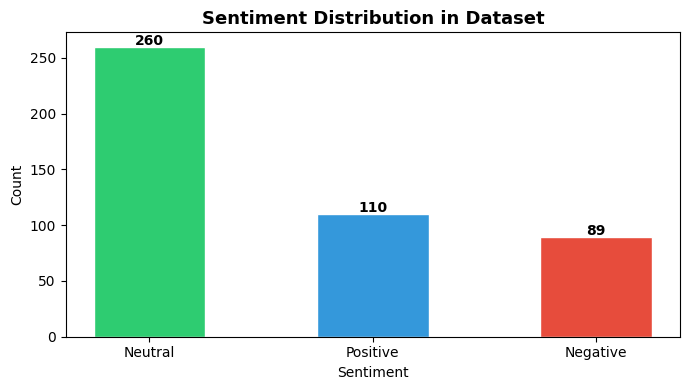

In [ ]:
# Rule-based sentiment from domain knowledge:
#   POSITIVE : Large Cap + High/Medium Sales
#   NEGATIVE : Very Small Cap + Very Low/Low Sales
#   NEUTRAL  : Everything else

def assign_sentiment(row):
    cap   = row['Market_Cap_Category']
    sales = row['Sales_Qrt_Category']
    if cap == 'Large Cap' and sales in ['High Sales', 'Medium Sales']:
        return 'Positive'
    elif cap == 'Very Small Cap' and sales in ['Very Low Sales', 'Low Sales']:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df.apply(assign_sentiment, axis=1)

print('── Sentiment Distribution ──')
print(df['Sentiment'].value_counts())

# Plot distribution
fig, ax = plt.subplots(figsize=(7, 4))
counts = df['Sentiment'].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=['#2ecc71', '#3498db', '#e74c3c'], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', fontweight='bold')
ax.set_title('Sentiment Distribution in Dataset', fontsize=13, fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
# Create 12 features from raw columns
df['MarCap_log']         = np.log1p(df['Mar Cap - Crore'])
df['Sales_log']          = np.log1p(df['Sales Qtr - Crore'])
df['MarCap_Sales_ratio'] = df['Mar Cap - Crore'] / (df['Sales Qtr - Crore'] + 1)
df['Ratio_log']          = np.log1p(df['MarCap_Sales_ratio'])

cap_dummies   = pd.get_dummies(df['Market_Cap_Category'], prefix='Cap')
sales_dummies = pd.get_dummies(df['Sales_Qrt_Category'],  prefix='Sales')

feature_df = pd.concat([
    df[['MarCap_log', 'Sales_log', 'MarCap_Sales_ratio', 'Ratio_log']],
    cap_dummies,
    sales_dummies
], axis=1)

print(f'Total features: {feature_df.shape[1]}')
print(f'Feature names: {feature_df.columns.tolist()}')
feature_df.head()

Total features: 12
Feature names: ['MarCap_log', 'Sales_log', 'MarCap_Sales_ratio', 'Ratio_log', 'Cap_Large Cap', 'Cap_Mid Cap', 'Cap_Small Cap', 'Cap_Very Small Cap', 'Sales_High Sales', 'Sales_Low Sales', 'Sales_Medium Sales', 'Sales_Very Low Sales']


,MarCap_log,Sales_log,MarCap_Sales_ratio,Ratio_log,Cap_Large Cap,Cap_Mid Cap,Cap_Small Cap,Cap_Very Small Cap,Sales_High Sales,Sales_Low Sales,Sales_Medium Sales,Sales_Very Low Sales
0,13.276693,11.511034,5.845415,1.923579,True,False,False,False,True,False,False,False
1,13.242297,10.338673,18.240085,2.956996,True,False,False,False,True,False,False,False
2,13.087678,9.932185,23.464544,3.197225,True,False,False,False,True,False,False,False
3,12.679154,9.187381,32.844021,3.521762,True,False,False,False,True,False,False,False
4,12.575905,9.731602,17.189514,2.900845,True,False,False,False,True,False,False,False


In [ ]:
# Encode labels
label_encoder = LabelEncoder()
y_encoded     = label_encoder.fit_transform(df['Sentiment'])
class_names   = label_encoder.classes_
num_classes   = len(class_names)
print(f'Classes: {list(zip(range(num_classes), class_names))}')

# Scale features
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(feature_df)

# Reshape for CNN: (samples, timesteps, channels=1)
X = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)
y = y_encoded

print(f'Input tensor shape : {X.shape}')
print(f'Label shape        : {y.shape}')

Classes: [(0, 'Negative'), (1, 'Neutral'), (2, 'Positive')]
Input tensor shape : (459, 12, 1)
Label shape        : (459,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train samples : {X_train.shape[0]}')
print(f'Test  samples : {X_test.shape[0]}')

classes           = np.unique(y_train)
weights           = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print(f'\nClass weights: {class_weight_dict}')

Train samples : 367
Test  samples : 92

Class weights: {np.int64(0): np.float64(1.7230046948356808), np.int64(1): np.float64(0.5881410256410257), np.int64(2): np.float64(1.3901515151515151)}


In [ ]:
def build_cnn(input_shape, num_classes,
              filter_sizes=(2, 3, 5), num_filters=64, dropout=0.4):

    inputs = Input(shape=input_shape, name='input')

    pooled_outputs = []
    for k in filter_sizes:
        k_clipped = min(k, input_shape[0])
        conv = Conv1D(
            filters=num_filters, kernel_size=k_clipped,
            activation='relu', padding='same',
            name=f'conv_k{k_clipped}'
        )(inputs)
        pool = GlobalMaxPooling1D(name=f'pool_k{k_clipped}')(conv)
        pooled_outputs.append(pool)

    merged = Concatenate(name='concat')(pooled_outputs)
    x      = BatchNormalization(name='batchnorm')(merged)
    x      = Dropout(dropout, name='dropout')(x)
    x      = Dense(64, activation='relu', name='dense_64')(x)
    output = Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inputs, outputs=output, name='FinancialCNN')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_cnn(
    input_shape=(X_train.shape[1], 1),
    num_classes=num_classes
)
model.summary()

Model: "FinancialCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 12, 1)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k2 (Conv1D)    │ (None, 12, 64)    │        192 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k3 (Conv1D)    │ (None, 12, 64)    │        256 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k5 (Conv1D)    │ (None, 12, 64)    │        384 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_k2             │ (None, 64)        │          0 │ conv_k2[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_k3             │ (None, 64)        │          0 │ conv_k3[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_k5             │ (None, 64)        │          0 │ conv_k5[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 192)       │          0 │ pool_k2[0][0],    │
│ (Concatenate)       │                   │            │ pool_k3[0][0],    │
│                     │                   │            │ pool_k5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batchnorm           │ (None, 192)       │        768 │ concat[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 192)       │          0 │ batchnorm[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_64 (Dense)    │ (None, 64)        │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        195 │ dense_64[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,147 (55.26 KB)

 Trainable params: 13,763 (53.76 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=10,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=5, min_lr=1e-6, verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.15,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 203ms/step - accuracy: 0.6592 - loss: 0.9727 - val_accuracy: 0.2143 - val_loss: 1.1693 - learning_rate: 0.0010
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8650 - loss: 0.3503 - val_accuracy: 0.2679 - val_loss: 1.1019 - learning_rate: 0.0010
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8939 - loss: 0.2650 - val_accuracy: 0.5179 - val_loss: 0.9748 - learning_rate: 0.0010
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9357 - loss: 0.1794 - val_accuracy: 0.8571 - val_loss: 0.9248 - learning_rate: 0.0010
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9357 - loss: 0.2497 - val_accuracy: 0.6250 - val_loss: 0.9245 - learning_rate: 0.0010
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9518 - loss: 0.1402 - val_accuracy: 0.7143 - val_loss: 0.8987 - learning_rate: 0.0010
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9646 - loss: 0.1433 - val_a

In [ ]:
y_pred_probs = model.predict(X_test)
y_pred       = np.argmax(y_pred_probs, axis=1)
accuracy     = accuracy_score(y_test, y_pred)

print('=' * 60)
print('  EVALUATION RESULTS')
print('=' * 60)
print(f'\nTest Accuracy : {accuracy * 100:.2f}%')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
print(f'Confusion Matrix:\n{cm}')

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 264ms/step
  EVALUATION RESULTS

Test Accuracy : 97.83%

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        18
     Neutral       1.00      0.96      0.98        52
    Positive       0.92      1.00      0.96        22

    accuracy                           0.98        92
   macro avg       0.97      0.99      0.98        92
weighted avg       0.98      0.98      0.98        92

Confusion Matrix:
[[18  0  0]
 [ 0 50  2]
 [ 0  0 22]]


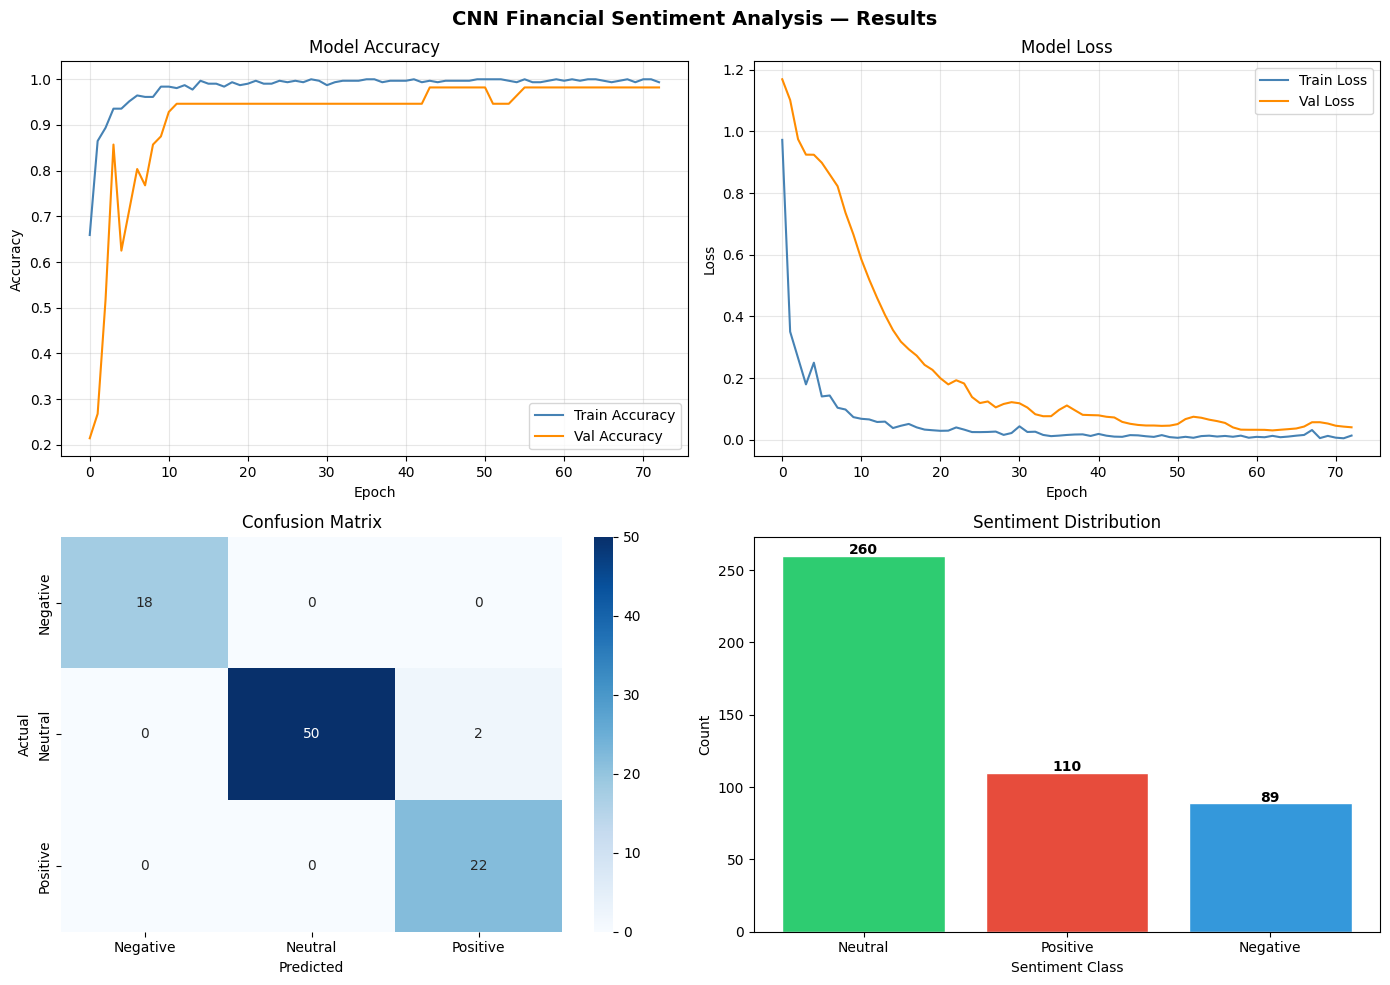

✔ Plot saved as cnn_results.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('CNN Financial Sentiment Analysis — Results',
             fontsize=14, fontweight='bold')

# Accuracy curve
ax = axes[0, 0]
ax.plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
ax.plot(history.history['val_accuracy'], label='Val Accuracy',   color='darkorange')
ax.set_title('Model Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# Loss curve
ax = axes[0, 1]
ax.plot(history.history['loss'],     label='Train Loss', color='steelblue')
ax.plot(history.history['val_loss'], label='Val Loss',   color='darkorange')
ax.set_title('Model Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Confusion matrix
ax = axes[1, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

# Sentiment distribution
ax = axes[1, 1]
counts = df['Sentiment'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db']
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontweight='bold')
ax.set_title('Sentiment Distribution')
ax.set_xlabel('Sentiment Class')
ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('cnn_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✔ Plot saved as cnn_results.png')

In [ ]:
def predict_sentiment(mar_cap_crore, sales_qtr_crore):
    """
    Predict financial sentiment for a company.
    Args:
        mar_cap_crore    : Market Capitalization in Crore INR
        sales_qtr_crore  : Quarterly Sales in Crore INR
    """
    if mar_cap_crore >= 100000:
        cap_cat = 'Large Cap'
    elif mar_cap_crore >= 50000:
        cap_cat = 'Mid Cap'
    elif mar_cap_crore >= 10000:
        cap_cat = 'Small Cap'
    else:
        cap_cat = 'Very Small Cap'

    if sales_qtr_crore >= 10000:
        sales_cat = 'High Sales'
    elif sales_qtr_crore >= 2000:
        sales_cat = 'Medium Sales'
    elif sales_qtr_crore >= 500:
        sales_cat = 'Low Sales'
    else:
        sales_cat = 'Very Low Sales'

    mar_cap_log = np.log1p(mar_cap_crore)
    sales_log   = np.log1p(sales_qtr_crore)
    ratio       = mar_cap_crore / (sales_qtr_crore + 1)
    ratio_log   = np.log1p(ratio)

    cap_cats   = ['Large Cap', 'Mid Cap', 'Small Cap', 'Very Small Cap']
    sales_cats = ['High Sales', 'Low Sales', 'Medium Sales', 'Very Low Sales']
    cap_oh     = [1 if cap_cat == c else 0 for c in cap_cats]
    sales_oh   = [1 if sales_cat == s else 0 for s in sales_cats]

    features        = np.array([[mar_cap_log, sales_log, ratio, ratio_log] + cap_oh + sales_oh])
    features_scaled = scaler.transform(features)
    features_3d     = features_scaled.reshape(1, features_scaled.shape[1], 1)

    probs     = model.predict(features_3d, verbose=0)[0]
    predicted = label_encoder.inverse_transform([np.argmax(probs)])[0]

    print(f'\n── Prediction ──')
    print(f'  Market Cap      : ₹{mar_cap_crore:,.2f} Cr  ({cap_cat})')
    print(f'  Quarterly Sales : ₹{sales_qtr_crore:,.2f} Cr  ({sales_cat})')
    print(f'  Predicted Sentiment : {predicted}')
    print(f'  Class Probabilities :')
    for cls, prob in zip(class_names, probs):
        bar = '█' * int(prob * 30)
        print(f'    {cls:<10} {prob:.4f}  {bar}')
    return predicted, probs

# --- Test predictions ---
print('=' * 60)
print('  SAMPLE PREDICTIONS')
print('=' * 60)

# Reliance Industries → expect Positive
predict_sentiment(583436.72, 99810.0)

# Very small cap, very low sales → expect Negative
predict_sentiment(4500.0, 120.0)

# Mid cap, medium sales → expect Neutral
predict_sentiment(45000.0, 1800.0)

  SAMPLE PREDICTIONS

── Prediction ──
  Market Cap      : ₹583,436.72 Cr  (Large Cap)
  Quarterly Sales : ₹99,810.00 Cr  (High Sales)
  Predicted Sentiment : Positive
  Class Probabilities :
    Negative   0.0000  
    Neutral    0.0000  
    Positive   1.0000  █████████████████████████████

── Prediction ──
  Market Cap      : ₹4,500.00 Cr  (Very Small Cap)
  Quarterly Sales : ₹120.00 Cr  (Very Low Sales)
  Predicted Sentiment : Negative
  Class Probabilities :
    Negative   0.9987  █████████████████████████████
    Neutral    0.0013  
    Positive   0.0000  

── Prediction ──
  Market Cap      : ₹45,000.00 Cr  (Small Cap)
  Quarterly Sales : ₹1,800.00 Cr  (Low Sales)
  Predicted Sentiment : Neutral
  Class Probabilities :
    Negative   0.0000  
    Neutral    1.0000  █████████████████████████████
    Positive   0.0000  


('Neutral',
 array([2.0376101e-06, 9.9999249e-01, 5.5378796e-06], dtype=float32))

In [ ]:
from google.colab import files
files.download('cnn_results.png')
print('nn_results.png downloaded!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✔ cnn_results.png downloaded!
